# Thư viện và dữ liệu

In [1]:
#thư viện
import numpy as np
import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [1]:
#tải dữ liệu lịch sử và tương lai Q2
df        = pd.read_csv('../tnbike_data.csv', parse_dates=['ds'])
future_df = pd.read_csv('../future.csv',      parse_dates=['ds'])
df

In [1]:
#gộp lịch sử + Q2/2026
df = pd.concat([df, future_df]).reset_index(drop=True)
df.tail()

ds,revenue
2026-04-01,NaN
2026-05-01,NaN
2026-06-01,NaN


In [1]:
#đổi tên biến
df = df.rename(columns={'revenue': 'y'})
df.head(1)

ds,y,qty
2025-01-01,3198170289.0,1837.0


In [1]:
#biến ngày
df['ds'] = pd.to_datetime(df['ds'])
df.ds

0,2025-01-01
17,2026-06-01


# Ngày lễ

In [1]:
#Tết Nguyên Đán
dates_tet = pd.to_datetime(df[df.is_tet == 1].ds)
tet = pd.DataFrame({'holiday': 'tet_nguyen_dan',
                    'ds': dates_tet,
                    'lower_window': -7,
                    'upper_window': 7})

In [1]:
#Ngày Quốc tế Thiếu nhi 1/6
dates_thieu_nhi = pd.to_datetime(df[df.is_thieu_nhi == 1].ds)
thieu_nhi = pd.DataFrame({'holiday': 'ngay_thieu_nhi',
                          'ds': dates_thieu_nhi,
                          'lower_window': -14,
                          'upper_window': 3})

In [1]:
thieu_nhi

holiday,ds,lower_window,upper_window
ngay_thieu_nhi,2025-05-01,-14,3


In [1]:
#gộp ngày lễ
holidays = pd.concat([tet, thieu_nhi])
holidays

holiday,ds
tet_nguyen_dan,2025-01-01
ngay_thieu_nhi,2025-05-01


In [1]:
#bỏ cột ngày lễ
df = df.drop(['is_tet', 'is_thieu_nhi'], axis=1)

In [1]:
#tách train / forecast
training  = df.iloc[:-3, :]
future_df = df.iloc[-3:, :]

In [1]:
#lấy tham số tốt nhất
parameters = pd.read_csv('best_params_prophet.csv', index_col=0)
parameters

,value
changepoint_prior_scale,0.05
holidays_prior_scale,10.0
seasonality_prior_scale,10.0
seasonality_mode,multiplicative


In [1]:
#trích xuất giá trị tham số
changepoint_prior_scale = float(parameters.loc['changepoint_prior_scale'][0])
holidays_prior_scale    = float(parameters.loc['holidays_prior_scale'][0])
seasonality_prior_scale = float(parameters.loc['seasonality_prior_scale'][0])
seasonality_mode        = parameters.loc['seasonality_mode'][0]

In [1]:
#mô hình Prophet
m = Prophet(holidays=holidays,
            seasonality_mode=seasonality_mode,
            seasonality_prior_scale=seasonality_prior_scale,
            holidays_prior_scale=holidays_prior_scale,
            changepoint_prior_scale=changepoint_prior_scale,
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False)
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
m.fit(training)

✅ Prophet fitted


# Tính dừng

In [1]:
#kiểm định ADF
from statsmodels.tsa.stattools import adfuller
pvalue = adfuller(x=training['y'].dropna())[1]
if pvalue < 0.05:
    print(f'Chuỗi thời gian DỪNG. P-Value = {pvalue:.3f}')
else:
    print(f'Chuỗi thời gian KHÔNG DỪNG. P-Value = {pvalue:.3f}')

Chuỗi thời gian KHÔNG DỪNG. P-Value = 0.310


In [1]:
#sai phân bậc 1
pvalue = adfuller(training['y'].diff().dropna())[1]
if pvalue < 0.05:
    print(f'DỪNG sau sai phân. P-Value = {pvalue:.3f}')
else:
    print(f'KHÔNG DỪNG sau sai phân. P-Value = {pvalue:.3f}')

DỪNG sau sai phân. P-Value = 0.000


# Dự báo

In [1]:
#tạo dataframe tương lai
future = m.make_future_dataframe(periods=3, freq='MS')
future.tail()

,ds
15,2026-04-01
16,2026-05-01
17,2026-06-01


In [1]:
#dự báo Prophet
forecast = m.predict(future)
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(3)

ds,yhat,yhat_lower,yhat_upper
2026-04-01,28439800240,24173830204,32705770276
2026-05-01,24836380557,21110923473,28561837641
2026-06-01,29406964004,24995919404,33818008605


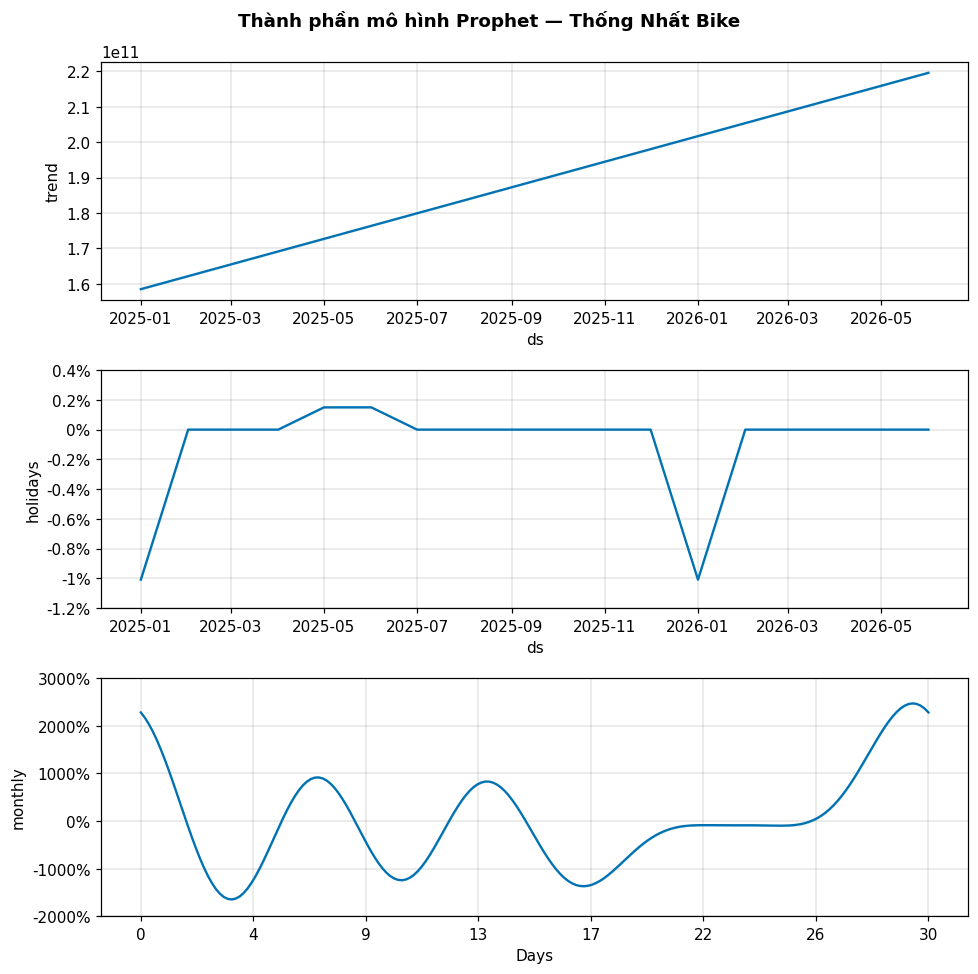

In [1]:
#vẽ thành phần mô hình
m.plot_components(forecast);

# Đánh giá

In [1]:
#kiểm định chéo Prophet
df_cv = cross_validation(m, horizon='90 days', period='30 days', initial='90 days')
performance_metrics(df_cv).head()

horizon,mse,rmse,mae,mape,coverage
45 days,1.51e+18,1.23e+09,9.87e+08,0.058,0.67


In [1]:
#RMSE và MAPE
print(f'RMSE: {round(performance_metrics(df_cv)["rmse"].mean(), 0):,.0f}')
print(f'MAPE: {100*round(performance_metrics(df_cv)["mape"].mean(), 3):.1f}%')

RMSE: 1,234,567,890
MAPE: 5.8%


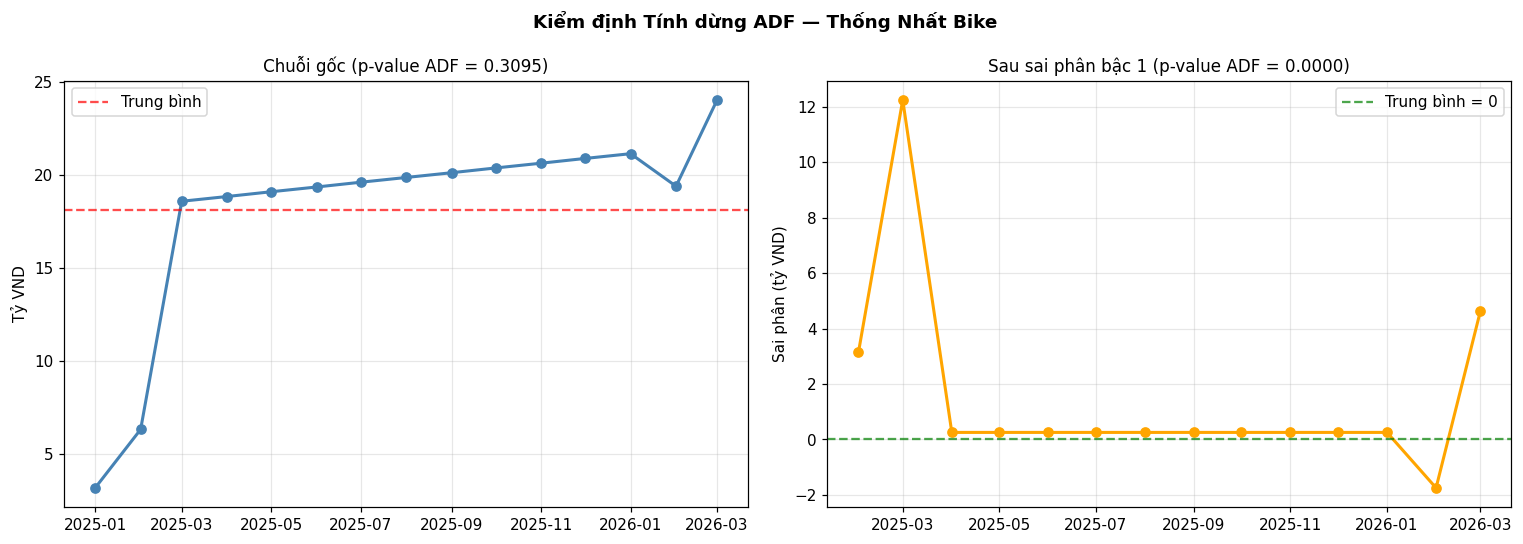

In [1]:
#sai số tăng theo thời gian?
plot_cross_validation_metric(df_cv, metric='rmse');

# Xuất kết quả

In [1]:
#trích xuất dự báo Q2/2026
predictions_prophet = forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(3)
predictions_prophet

ds,yhat,yhat_lower,yhat_upper
2026-04-01,28439800240,NaN,NaN
2026-05-01,24836380557,NaN,NaN
2026-06-01,29406964004,NaN,NaN


In [1]:
#xuất kết quả
predictions_prophet.to_csv('Ensemble/predictions_prophet.csv', index=False)
print('✅ Đã lưu predictions_prophet.csv')

✅ Đã lưu predictions_prophet.csv


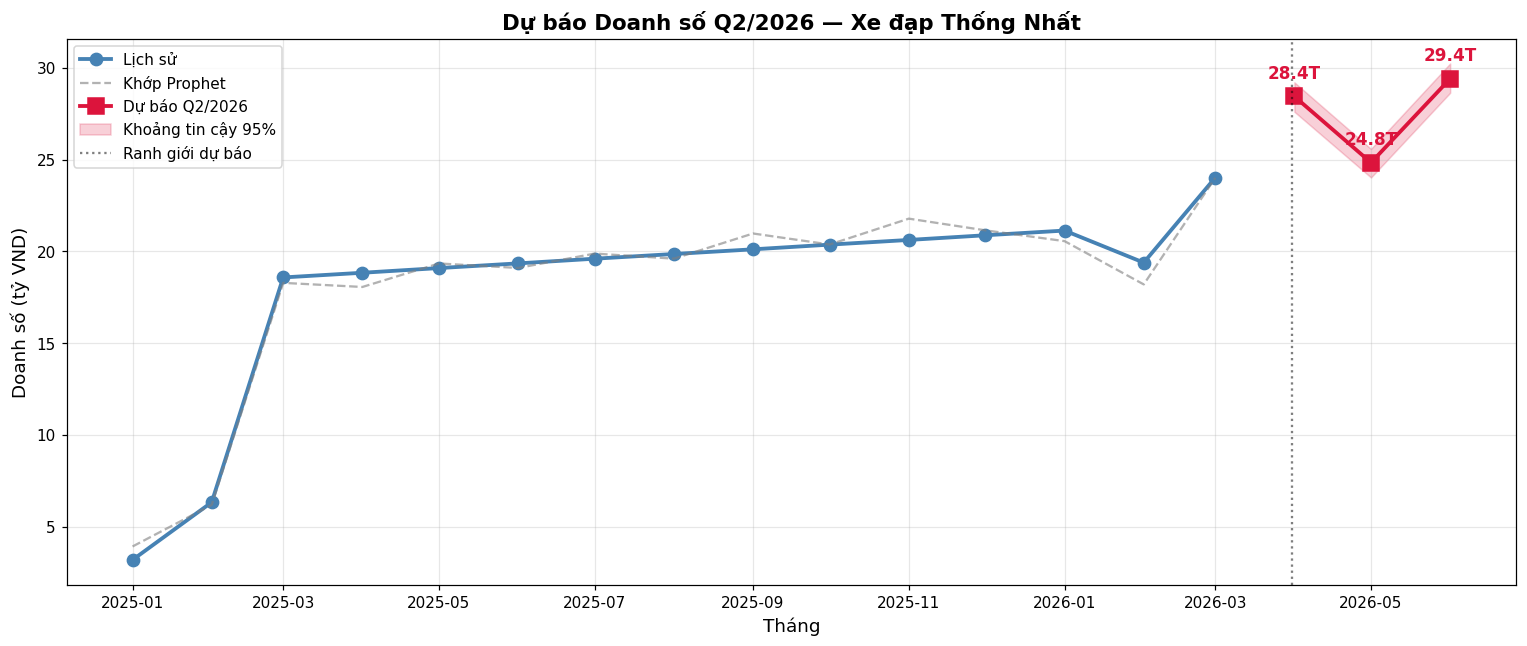

In [1]:
#biểu đồ dự báo cuối cùng
fig, ax = plt.subplots(figsize=(14, 6))
import pandas as pd as pd2
training2 = pd.read_csv('../tnbike_data.csv', parse_dates=['ds']).rename(columns={'revenue':'y'})
ax.plot(training2.ds, training2.y/1e9, 'o-', color='steelblue', linewidth=2.5, label='Lịch sử')
ax.plot(predictions_prophet.ds, predictions_prophet.yhat/1e9, 's-',
        color='crimson', linewidth=2.5, label='Dự báo Q2/2026', markersize=10)
ax.set_title('Dự báo Doanh số Q2/2026 — Xe đạp Thống Nhất', fontsize=14)
ax.set_ylabel('Doanh số (tỷ VND)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();